# 🌪️ StormCost — Predicting Property Damage from Storm Narratives
**Competition:** [StormCost on Kaggle](https://www.kaggle.com/competitions/storm-cost) · hosted by BTAJI Crew Community
**Approach:** frozen contextual sentence encoder + two-stage gradient boosting (occurrence → magnitude), validated **leave-years-out**, with metric-aware post-processing.

---
## 1. Problem in plain words
Each row is a severe-weather incident (hail, tornado, flood, ...). We get a short narrative written by an officer plus structured fields (state, year, magnitude, injuries...). We must predict **property damage in US dollars**.

The score has two equally weighted parts:

| Part | Question | Metric |
|---|---|---|
| Occurrence | Did *any* damage happen? | `2·balanced_accuracy − 1` (predicted `0` = "no damage") |
| Magnitude | If yes, how much? | `Σ min(ŷ,y) / Σ max(ŷ,y)` over truly damaged rows (dollar space, so big events dominate) |

`final = 1 + 99 · (0.5·occurrence + 0.5·magnitude)`  (all-zeros = 1, perfect = 100)

## 2. Solution overview
```
narratives ──► frozen MiniLM encoder ──► PCA ──┐
structured fields + era clues + episode stats ─┴─► LightGBM classifier  → P(damage)
                                                  LightGBM regressor   → log(damage | damage)
                                   P(damage) ≥ threshold ?  expm1(log-pred) × k(event type)  :  exactly 0
```
Key design choices (and why):
1. **Two-stage model** – the metric itself is two-headed, so we model both heads separately.
2. **Leave-years-out CV** – the test set comes from *different years* with an older-era skew; random CV would be over-optimistic.
3. **Metric-aware post-processing** – a log-trained regressor under-predicts the tail, but the score is in dollars. We tune a decision threshold and dollar scale factors `k`, and check them with *nested* validation so tuning itself isn't flattering us.
4. **Rule-compliant text modelling** – only a pretrained contextual encoder (frozen). No TF-IDF / bag-of-words / n-gram counters / averaged static embeddings.

## 3. Competition-rules compliance
| Rule | How this notebook complies |
|---|---|
| Text representation must be a learned contextual encoder | `sentence-transformers/all-MiniLM-L6-v2`, frozen, from the permitted list |
| No TF-IDF, BoW, n-gram counters, one-hot token matrices, averaged Word2Vec/GloVe/FastText | None used |
| `episode_group` not a model feature | Only used for CV logic and to compute label-free group statistics (size, injury/death totals), **computed within each file separately** as the data page allows |
| Don't train on the `-1.0` placeholder | Test labels are never used (asserted) |
| Group CV and no tuning to the public LB | Leave-years-out CV; the public LB is never consulted |
| Predictions finite & non-negative, one row per `sample_id`, exact `0.0` for "no damage" | Validated before saving |
| Runtime: ≤ 3 h CPU / ≤ 1.5 h single GPU, training included | Stage timings are logged and asserted at the end |
| No real-world lookup of the source database | No external data used |

> **How to run:** Colab → *Runtime → Change runtime type → T4 GPU*, add your Kaggle token to *Secrets* as `Storm_Comptition`, join the competition (accept its rules), then **Runtime → Run all**.

## 4. Setup & configuration
**In simple words:** install libraries, import them, and put every adjustable setting in one place (`CFG`) so the whole experiment is reproducible. We also fix random seeds and add a small stopwatch to time each stage (the competition has a runtime limit).

In [2]:
!pip -q install kagglehub sentence-transformers lightgbm

In [3]:
import os, glob, time, random, warnings, contextlib, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 220)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

CFG = dict(
    seed=42,
    n_seeds=1,                       # raise to 3 for a slightly stronger (slower) final run
    n_splits=5,
    encoder="sentence-transformers/all-MiniLM-L6-v2",
    event_pca=64, episode_pca=16,
    event_max_len=128, episode_max_len=256, encode_batch=256,
    use_redaction_count=True,        # count of "[REDACTED]" tokens: tells us a $ amount / date was mentioned
    lgb=dict(n_estimators=1000, learning_rate=0.08, num_leaves=63, min_child_samples=50,
             subsample=0.8, subsample_freq=1, colsample_bytree=0.7, reg_lambda=1.0, n_jobs=-1, verbose=-1),
    thr_grid=[round(x, 2) for x in np.arange(0.10, 0.80, 0.05)],
    k_grid=[0.5, 0.75, 1, 1.5, 2, 3, 5, 8, 12],
    min_damaged_for_type_k=500,      # event types need this many damaged rows to get their own scale factor
    runtime_budget_min=dict(gpu=90, cpu=180),
)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def seed_everything(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything(CFG["seed"])

STAGE_TIMES = {}
@contextlib.contextmanager
def stage(name):
    t0 = time.time(); print(f"▶ {name} ...")
    try:
        yield
    finally:
        STAGE_TIMES[name] = time.time() - t0
        print(f"✔ {name}: {STAGE_TIMES[name]/60:.1f} min")

print("Device:", DEVICE)

Device: cuda


## 5. Load the data
**In simple words:** download the competition files with your Kaggle token (kept safe in Colab Secrets, never typed into the notebook) and find the three CSVs.

In [4]:
import kagglehub
from google.colab import userdata

# Retrieve token securely from Colab Secrets
os.environ["KAGGLE_API_TOKEN"] = userdata.get('Storm_Comptition')

# Download latest version
path = kagglehub.competition_download('storm-cost')

print("Path to competition files:", path)

100%|██████████| 151M/151M [00:10<00:00, 15.6MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/storm-cost


In [5]:
def find_file(name):
    hits = glob.glob(os.path.join(path, "**", name), recursive=True)
    if not hits:                                   # fallback: files may still be zipped
        for z in glob.glob(os.path.join(path, "**", "*.zip"), recursive=True):
            zipfile.ZipFile(z).extractall(os.path.dirname(z))
        hits = glob.glob(os.path.join(path, "**", name), recursive=True)
    assert hits, f"{name} not found under {path}"
    return hits[0]

with stage("Load data"):
    train = pd.read_csv(find_file("train.csv"))
    test = pd.read_csv(find_file("test.csv"))
    sample_sub = pd.read_csv(find_file("sample_submission.csv"))

print(f"train {train.shape} | test {test.shape} | sample_submission {sample_sub.shape}")
train.head(3)

▶ Load data ...
✔ Load data: 0.2 min
train (358976, 20) | test (229965, 20) | sample_submission (229965, 2)


,sample_id,episode_group,year,month_name,state,event_type,lon,lat,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect,magnitude,magnitude_type,tor_f_scale,tor_length,tor_width,event_narrative_redacted,episode_narrative_redacted,damage_property_usd
0,evt_1b1ac980efca9da9,epi_61053374345acb4c,2008,May,IOWA,Flash Flood,-91.894,42.563,0,0,0,0,NaN,none,none,NaN,NaN,Heavy rain resulted in a rapid rise on Buffalo Creek during the early morning of [REDACTED] . The river level rose about 4 feet and is o...,Heavy rain-producing showers and thunderstorms moved repeatedly across areas mainly north of Interstate 80 on [REDACTED] dumping 1 to 5 ...,0.0
1,evt_a2099de57287f189,epi_96e8123a57cb8537,2011,September,GEORGIA,Thunderstorm Wind,-84.369,31.534,0,0,0,0,50.0,eg,none,NaN,NaN,A tree was blown down near the intersection of Harvest Lane and Phillips Drive. The monetary damage figure provided is a rough estimate.,A fairly widespread outbreak of severe thunderstorms occurred on Labor Day across much of the NWS Tallahassee County Warning Area (CWA)....,1000.0
2,evt_8b79a00bdd5e70bb,epi_a8f7f01992ea521f,2011,June,SOUTH CAROLINA,Thunderstorm Wind,-80.097,32.931,0,0,0,0,50.0,eg,none,NaN,NaN,A NWS employee reported 1 large limb down along Appian Way.,Clusters of thunderstorms developed near a long-wave trough east of South Carolina. Thunderstorms became strong as they entered an unsta...,500.0


## 6. Data audit (sanity checks)
**In simple words:** before modelling, make sure the data is what the competition says it is. If any `assert` fails, something is wrong with the download — better to find out now.

In [6]:
TARGET = "damage_property_usd"
expected = {"sample_id","episode_group","year","month_name","state","event_type","lon","lat","injuries_direct",
            "injuries_indirect","deaths_direct","deaths_indirect","magnitude","magnitude_type","tor_f_scale",
            "tor_length","tor_width","event_narrative_redacted","episode_narrative_redacted"}
assert expected <= set(train.columns) and expected <= set(test.columns), "missing columns"
assert TARGET in train.columns
assert (train[TARGET] >= 0).all(), "negative labels in train?"
assert (test[TARGET] == -1.0).all(), "test placeholder should be -1.0 (and we never use it)"
assert train["sample_id"].is_unique and test["sample_id"].is_unique
assert set(test["sample_id"]) == set(sample_sub["sample_id"]), "test ids != sample submission ids"

overlap = len(set(train["episode_group"]) & set(test["episode_group"]))
print("✅ schema OK | episode groups shared by train and test:", overlap)
print("\nMissing values (share of rows):")
print(train[["magnitude","magnitude_type","tor_length","episode_narrative_redacted"]].isna().mean().round(3).to_string())

✅ schema OK | episode groups shared by train and test: 0

Missing values (share of rows):
magnitude                     0.499
magnitude_type                0.000
tor_length                    0.964
episode_narrative_redacted    0.025


## 7. Exploratory data analysis
**In simple words:** look at pictures of the data to learn three things that shape every later decision: (1) how heavy-tailed the damage is, (2) which event types are damaging, (3) how different the train and test *years* are.

Zero-damage share: 62.6%
Median / 90th / 99th pct of damaged rows: $10,000 / $160,000 / $6,250,000
Top 1% of damaged rows hold 87.7% of all dollars


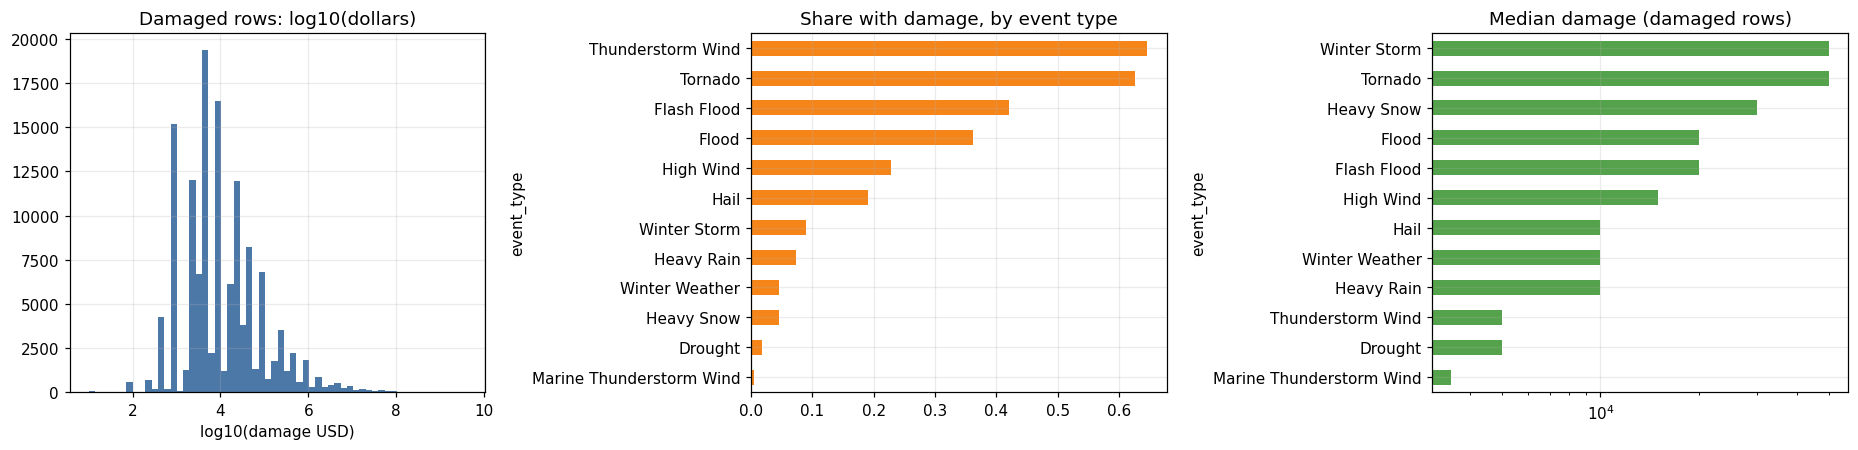

In [7]:
y = train[TARGET]
dmg = y[y > 0]
top1 = dmg.sort_values(ascending=False).head(int(len(dmg) * 0.01))
print(f"Zero-damage share: {(y == 0).mean():.1%}")
print(f"Median / 90th / 99th pct of damaged rows: ${dmg.median():,.0f} / ${dmg.quantile(.9):,.0f} / ${dmg.quantile(.99):,.0f}")
print(f"Top 1% of damaged rows hold {top1.sum() / dmg.sum():.1%} of all dollars")

fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
ax[0].hist(np.log10(dmg), bins=60, color="#4c78a8"); ax[0].set_title("Damaged rows: log10(dollars)")
ax[0].set_xlabel("log10(damage USD)")

top_types = train["event_type"].value_counts().head(12).index
rate = train[train.event_type.isin(top_types)].groupby("event_type")[TARGET].apply(lambda s: (s > 0).mean()).sort_values()
rate.plot.barh(ax=ax[1], color="#f58518"); ax[1].set_title("Share with damage, by event type")

med = train[train.event_type.isin(top_types) & (y > 0)].groupby("event_type")[TARGET].median().sort_values()
med.plot.barh(ax=ax[2], color="#54a24b", logx=True); ax[2].set_title("Median damage (damaged rows)")
plt.tight_layout(); plt.show()

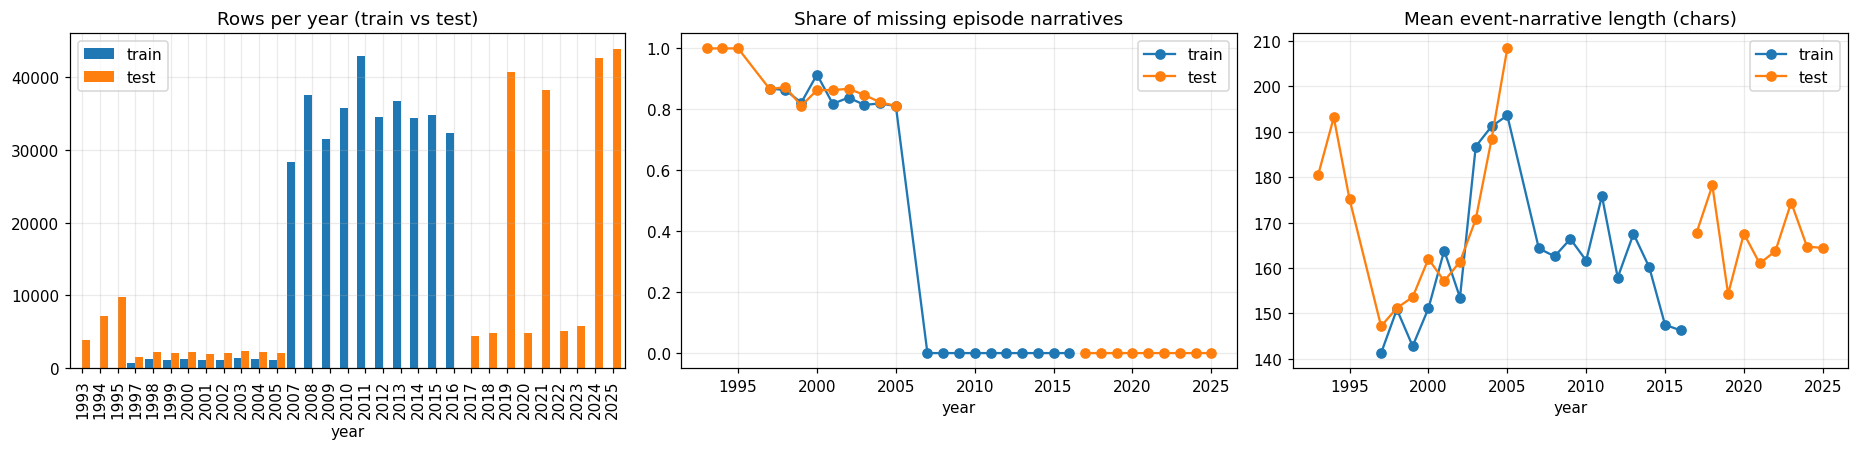

Train years: 1997 - 2016 | Test years: 1993 - 2025
Test years absent from train: [1993, 1994, 1995, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [8]:
yr = pd.DataFrame({"train": train.year.value_counts().sort_index(), "test": test.year.value_counts().sort_index()}).fillna(0)
miss = pd.DataFrame({
    "train": train.groupby("year")["episode_narrative_redacted"].apply(lambda s: s.isna().mean()),
    "test": test.groupby("year")["episode_narrative_redacted"].apply(lambda s: s.isna().mean())})
length = pd.DataFrame({
    "train": train.groupby("year")["event_narrative_redacted"].apply(lambda s: s.fillna("").str.len().mean()),
    "test": test.groupby("year")["event_narrative_redacted"].apply(lambda s: s.fillna("").str.len().mean())})

fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
yr.plot.bar(ax=ax[0], width=0.9); ax[0].set_title("Rows per year (train vs test)")
miss.plot(ax=ax[1], marker="o"); ax[1].set_title("Share of missing episode narratives")
length.plot(ax=ax[2], marker="o"); ax[2].set_title("Mean event-narrative length (chars)")
plt.tight_layout(); plt.show()

print("Train years:", train.year.min(), "-", train.year.max(), "| Test years:", test.year.min(), "-", test.year.max())
print("Test years absent from train:", sorted(set(test.year) - set(train.year)))

**What the plots tell us**
- Damage is extremely heavy-tailed → a few huge events dominate the dollar metric, so we must not shrink predictions toward the mean.
- Damage rate and size depend strongly on event type → event type (and later, a per-type scale factor) matters.
- Train and test cover **different years**, and older years have shorter narratives and many missing episode texts → we need era-aware validation (leave-years-out) and features that expose the era (`year`, `episode_missing`, lengths).

## 8. Feature engineering — structured fields
**In simple words:** convert the table columns into clean numeric clues. Categories stay categories (LightGBM handles them natively). Blank injuries/deaths become 0 (as the rules say), but blank magnitude stays *blank* (NaN) — a missing measurement is not the same as zero.

Extra clues we add:
- **Era clues:** narrative lengths, word counts and "episode narrative missing" flag.
- **Episode statistics:** group size, total injuries and deaths in the episode. Computed **inside each file separately** and without any label, as allowed by the data page.
- **Redaction count:** how many `[REDACTED]` tokens appear. A redaction means a dollar amount or date was written in the original — a mild but legitimate signal. This is a single numeric count, not a token-count representation of the text. It can be switched off via `CFG["use_redaction_count"]`.

In [9]:
MONTHS = ["January","February","March","April","May","June","July","August","September","October","November","December"]

def build_tabular_features(full, n_train):
    X = pd.DataFrame(index=full.index)
    for c in ["year", "lon", "lat", "magnitude", "tor_length", "tor_width"]:
        X[c] = pd.to_numeric(full[c], errors="coerce")
    for c in ["injuries_direct", "injuries_indirect", "deaths_direct", "deaths_indirect"]:
        X[c] = pd.to_numeric(full[c], errors="coerce").fillna(0)
    X["month"] = full["month_name"].map({m: i + 1 for i, m in enumerate(MONTHS)})
    for c in ["event_type", "state", "magnitude_type", "tor_f_scale"]:
        X[c] = full[c].fillna("none").astype(str).astype("category")

    ev = full["event_narrative_redacted"].fillna("")
    ep = full["episode_narrative_redacted"].fillna("")
    X["event_len"] = ev.str.len()
    X["event_words"] = ev.str.split().str.len()
    X["episode_len"] = ep.str.len()
    X["episode_missing"] = full["episode_narrative_redacted"].isna().astype(int)
    if CFG["use_redaction_count"]:
        X["event_n_redacted"] = ev.str.count(r"\[REDACTED\]")
        X["episode_n_redacted"] = ep.str.count(r"\[REDACTED\]")

    # episode statistics, computed separately inside train and inside test (no labels involved)
    split = np.where(np.arange(len(full)) < n_train, "train", "test")
    g = full.assign(_split=split).groupby(["_split", "episode_group"])
    X["group_size"] = g["sample_id"].transform("size")
    X["group_injuries"] = g["injuries_direct"].transform("sum")
    X["group_deaths"] = g["deaths_direct"].transform("sum")
    return X, ev, ep

with stage("Tabular features"):
    full = pd.concat([train.drop(columns=[TARGET]), test], ignore_index=True)   # labels never enter `full`
    n_train = len(train)
    X_tab, ev_text, ep_text = build_tabular_features(full, n_train)
print(X_tab.shape)
X_tab.head(3)

▶ Tabular features ...
✔ Tabular features: 0.2 min
(588941, 24)


,year,lon,lat,magnitude,tor_length,tor_width,injuries_direct,injuries_indirect,deaths_direct,deaths_indirect,...,tor_f_scale,event_len,event_words,episode_len,episode_missing,event_n_redacted,episode_n_redacted,group_size,group_injuries,group_deaths
0,2008,-91.894,42.563,NaN,NaN,NaN,0,0,0,0,...,none,256,48,296,0,1,1,6,0,0
1,2011,-84.369,31.534,50.0,NaN,NaN,0,0,0,0,...,none,136,23,1555,0,0,3,18,1,0
2,2011,-80.097,32.931,50.0,NaN,NaN,0,0,0,0,...,none,59,11,355,0,0,1,8,0,0


## 9. Feature engineering — reading the narratives 📖
**In simple words:** a pretrained language model (`all-MiniLM-L6-v2`) reads each narrative and returns 384 numbers capturing its *meaning and word order* ("roof torn off" ≈ "roof ripped away"). The model is **frozen** — we only use it to read, never train it.

Speed tricks:
- Episode narratives are shared by many rows, so every **unique** text is encoded only once and copied back.
- 384 numbers are squeezed with **PCA** to 64 (event) / 16 (episode) so the boosting models stay fast. PCA is fitted on text only — no labels.
- Results are cached on disk, so a re-run skips this step.

In [10]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

CACHE = "/content/cache"; os.makedirs(CACHE, exist_ok=True)
encoder = SentenceTransformer(CFG["encoder"], device=DEVICE)
if DEVICE == "cuda":
    encoder.half()

def embed_unique(texts, n_components, max_len, tag):
    cache_file = f"{CACHE}/{tag}_{n_components}.npy"
    codes, uniques = pd.factorize(texts)                      # codes[i] -> which unique text row i uses
    if os.path.exists(cache_file):
        reduced = np.load(cache_file)
    else:
        encoder.max_seq_length = max_len
        emb = encoder.encode(list(uniques), batch_size=CFG["encode_batch"], show_progress_bar=True,
                             convert_to_numpy=True, normalize_embeddings=True)
        reduced = PCA(n_components=n_components, random_state=CFG["seed"]).fit_transform(emb).astype("float32")
        np.save(cache_file, reduced)
    print(f"{tag}: {len(uniques):,} unique texts -> {len(texts):,} rows")
    return reduced[codes]

with stage("Encode narratives"):
    ev_emb = embed_unique(ev_text, CFG["event_pca"], CFG["event_max_len"], "event")
    ep_emb = embed_unique(ep_text, CFG["episode_pca"], CFG["episode_max_len"], "episode")
print(ev_emb.shape, ep_emb.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

▶ Encode narratives ...


Batches:   0%|          | 0/2071 [00:00<?, ?it/s]

event: 529,966 unique texts -> 588,941 rows


Batches:   0%|          | 0/417 [00:00<?, ?it/s]

episode: 106,546 unique texts -> 588,941 rows
✔ Encode narratives: 4.6 min
(588941, 64) (588941, 16)


In [11]:
emb_cols = [f"ev_{i}" for i in range(ev_emb.shape[1])] + [f"ep_{i}" for i in range(ep_emb.shape[1])]
X_all = pd.concat([X_tab, pd.DataFrame(np.hstack([ev_emb, ep_emb]), columns=emb_cols, index=full.index)], axis=1)

X_train = X_all.iloc[:n_train].reset_index(drop=True)
X_test = X_all.iloc[n_train:].reset_index(drop=True)
y_train = train[TARGET].values
has_damage = (y_train > 0).astype(int)
log_y = np.log1p(y_train)
event_types_train = train["event_type"].values
event_types_test = test["event_type"].values

del ev_emb, ep_emb
print("Final feature matrix:", X_train.shape, X_test.shape)

Final feature matrix: (358976, 104) (229965, 104)


## 10. The competition metric (re-implemented)
**In simple words:** Kaggle's score isn't in any library, so we re-implement it exactly as written on the Evaluation page. We test it on easy cases where we know the answer: all zeros must give **1**, perfect must give **100**, and "2× the truth" must give magnitude **0.5**.

In [12]:
def stormcost_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.nan_to_num(np.asarray(y_pred, dtype=float), nan=0.0, posinf=1e12, neginf=0.0)
    y_pred = np.clip(y_pred, 0, 1e12)
    true_pos, pred_pos = y_true > 0, y_pred > 0
    sens = (pred_pos & true_pos).sum() / max(true_pos.sum(), 1)
    spec = (~pred_pos & ~true_pos).sum() / max((~true_pos).sum(), 1)
    occ = 2 * ((sens + spec) / 2) - 1
    t, p = y_true[true_pos], y_pred[true_pos]
    mag = np.minimum(t, p).sum() / max(np.maximum(t, p).sum(), 1e-12)
    return 1 + 99 * (0.5 * occ + 0.5 * mag), occ, mag

# unit tests of the metric
assert abs(stormcost_score(y_train, np.zeros(len(y_train)))[0] - 1) < 1e-9
assert abs(stormcost_score(y_train, y_train)[0] - 100) < 1e-9
assert abs(stormcost_score(y_train, 2 * y_train)[2] - 0.5) < 1e-9
print("✅ metric unit tests passed")
print("Constant-mean baseline:", [round(v, 3) for v in stormcost_score(y_train, np.full(len(y_train), y_train.mean()))])

✅ metric unit tests passed
Constant-mean baseline: [np.float64(3.063), np.float64(0.0), np.float64(0.042)]


## 11. Validation design: leave-years-out
**In simple words:** the test set is from *other years*. So we cut train into 5 folds where **each calendar year lives in exactly one fold**. We train on 4 folds and score on the 5th, 5 times. Every training row therefore gets a prediction from a model that never saw its year ("out-of-fold", OOF). This is stricter than random splitting — and much more honest.

We also verify that storms (episodes) are not split across folds, since rows from one storm are near-copies of each other.

In [13]:
from sklearn.model_selection import GroupKFold

folds = list(GroupKFold(n_splits=CFG["n_splits"]).split(X_train, groups=train["year"].values))
fold_id = np.zeros(len(train), dtype=int)
for i, (_, va) in enumerate(folds):
    fold_id[va] = i
    yrs = sorted(train["year"].iloc[va].unique())
    print(f"Fold {i}: years {yrs[0]}..{yrs[-1]} ({len(yrs)} yrs), {len(va):,} rows")

spans = pd.Series(fold_id).groupby(train["episode_group"].values).nunique()
print(f"\nEpisodes spanning more than one fold: {(spans > 1).mean():.3%}  (should be ~0)")

Fold 0: years 2005..2011 (3 yrs), 72,208 rows
Fold 1: years 1999..2009 (4 yrs), 71,484 rows
Fold 2: years 2001..2016 (4 yrs), 71,518 rows
Fold 3: years 1997..2014 (4 yrs), 72,013 rows
Fold 4: years 2000..2015 (4 yrs), 71,753 rows

Episodes spanning more than one fold: 0.000%  (should be ~0)


## 12. Model training — two heads
**In simple words:** for each fold we train two LightGBM models (many small decision trees):
1. **Classifier** → probability that damage > 0.
2. **Regressor** → `log(1 + damage)`, trained **only on rows that really had damage** (so it answers "given damage, how big?").

Both stop early when they stop improving. We save out-of-fold predictions (for honest tuning) and average the fold models' predictions for the test set. We also collect feature importances for later.

*Honest note:* early stopping looks at the validation fold, which makes OOF scores very slightly optimistic. The effect is small with 350k rows, but it's a known limitation (listed at the end).

In [14]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

def train_two_stage():
    n_seeds = CFG["n_seeds"]
    oof_p, oof_log = np.zeros(len(X_train)), np.zeros(len(X_train))
    test_p, test_log = np.zeros(len(X_test)), np.zeros(len(X_test))
    imp_clf = pd.Series(0.0, index=X_train.columns); imp_reg = pd.Series(0.0, index=X_train.columns)
    rows = []
    for s in range(n_seeds):
        params = dict(CFG["lgb"], random_state=CFG["seed"] + s)
        for i, (tr, va) in enumerate(folds):
            clf = lgb.LGBMClassifier(**params)
            clf.fit(X_train.iloc[tr], has_damage[tr], eval_set=[(X_train.iloc[va], has_damage[va])],
                    callbacks=[lgb.early_stopping(50, verbose=False)])
            oof_p[va] += clf.predict_proba(X_train.iloc[va])[:, 1] / n_seeds
            test_p += clf.predict_proba(X_test)[:, 1] / (len(folds) * n_seeds)
            imp_clf += pd.Series(clf.booster_.feature_importance("gain"), index=X_train.columns)

            tr_d, va_d = tr[has_damage[tr] == 1], va[has_damage[va] == 1]
            reg = lgb.LGBMRegressor(**params)
            reg.fit(X_train.iloc[tr_d], log_y[tr_d], eval_set=[(X_train.iloc[va_d], log_y[va_d])],
                    callbacks=[lgb.early_stopping(50, verbose=False)])
            oof_log[va] += reg.predict(X_train.iloc[va]) / n_seeds
            test_log += reg.predict(X_test) / (len(folds) * n_seeds)
            imp_reg += pd.Series(reg.booster_.feature_importance("gain"), index=X_train.columns)

            if s == 0:
                rows.append(dict(fold=i, auc=roc_auc_score(has_damage[va], oof_p[va] * n_seeds if n_seeds == 1 else oof_p[va]),
                                 log_rmse=float(np.sqrt(np.mean((reg.predict(X_train.iloc[va_d]) - log_y[va_d]) ** 2))),
                                 clf_trees=clf.best_iteration_, reg_trees=reg.best_iteration_))
            print(f"seed {s} fold {i} done")
    return oof_p, oof_log, test_p, test_log, imp_clf, imp_reg, pd.DataFrame(rows)

with stage("Train models (CV)"):
    oof_p, oof_log, test_p, test_log, imp_clf, imp_reg, fold_report = train_two_stage()

print(fold_report.round(3).to_string(index=False))
print(f"\nOverall OOF AUC: {roc_auc_score(has_damage, oof_p):.3f}")

▶ Train models (CV) ...
seed 0 fold 0 done
seed 0 fold 1 done
seed 0 fold 2 done
seed 0 fold 3 done
seed 0 fold 4 done
✔ Train models (CV): 18.5 min
 fold   auc  log_rmse  clf_trees  reg_trees
    0 0.954     1.295        580        727
    1 0.958     1.385        890        355
    2 0.967     1.327        931        681
    3 0.970     1.259        999        880
    4 0.964     1.243        815        871

Overall OOF AUC: 0.963


## 13. Turning model outputs into dollar predictions (metric-aware post-processing)
**In simple words:** the models give a *probability* and a *typical log-size*. The score needs *dollars*, and exact zeros for "no damage". Two settings convert one into the other:

- **Threshold:** if P(damage) < threshold → output exactly `0`. Lower = catch more damage, but also flag more clean rows.
- **Scale factor `k`:** multiply the dollar guess by `k`. Log-trained models underestimate rare giant events, but the metric is in dollars where giants dominate, so `k > 1` usually helps. We try a global `k` and, optionally, a separate `k` for each frequent event type.

**Avoiding self-deception:** tuning on the same predictions we score would be flattering. So we use **nested validation** — tune the settings on 4 folds, apply them to the 5th, repeat — and report that honest score. Only then do we tune on everything for the final test predictions.

In [15]:
mag_train = np.expm1(oof_log)
mag_test = np.expm1(test_log)

def apply_rule(p, mag, types, thr, k_global, k_by_type):
    k = np.full(len(p), float(k_global))
    for t, kv in k_by_type.items():
        k[types == t] = kv
    return np.where(p >= thr, mag * k, 0.0)

def tune(idx, per_type):
    p, m, ty, yt = oof_p[idx], mag_train[idx], event_types_train[idx], y_train[idx]
    best = (-1, None, None)
    for thr in CFG["thr_grid"]:
        for k in CFG["k_grid"]:
            s = stormcost_score(yt, apply_rule(p, m, ty, thr, k, {}))[0]
            if s > best[0]:
                best = (s, thr, k)
    _, thr, kg = best
    kmap = {}
    if per_type:
        counts = pd.Series(ty[yt > 0]).value_counts()
        eligible = counts[counts >= CFG["min_damaged_for_type_k"]].index
        cur = best[0]
        for t in eligible:                                   # one pass of coordinate search
            for k in CFG["k_grid"]:
                trial = dict(kmap); trial[t] = k
                s = stormcost_score(yt, apply_rule(p, m, ty, thr, kg, trial))[0]
                if s > cur:
                    cur, kmap = s, trial
    return dict(thr=thr, k_global=kg, k_by_type=kmap)

def nested_oof(per_type):
    pred = np.zeros(len(y_train))
    for i, (tr, va) in enumerate(folds):
        prm = tune(tr, per_type)
        pred[va] = apply_rule(oof_p[va], mag_train[va], event_types_train[va], prm["thr"], prm["k_global"], prm["k_by_type"])
    return pred

with stage("Tune thresholds / scale factors (nested)"):
    nested_global = nested_oof(per_type=False)
    nested_pertype = nested_oof(per_type=True)

res = {}
for name, pr in [("global k", nested_global), ("per-event-type k", nested_pertype)]:
    s, o, m = stormcost_score(y_train, pr); res[name] = (s, o, m, pr)
    print(f"Honest nested CV | {name:17s}: score={s:6.2f}  occurrence={o:.3f}  magnitude={m:.3f}")

USE_PER_TYPE = res["per-event-type k"][0] > res["global k"][0] + 0.05    # only use it if it clearly helps
chosen = "per-event-type k" if USE_PER_TYPE else "global k"
honest_pred = res[chosen][3]
cv_score, cv_occ, cv_mag = res[chosen][:3]
print(f"\n→ Using: {chosen}")

▶ Tune thresholds / scale factors (nested) ...
✔ Tune thresholds / scale factors (nested): 0.6 min
Honest nested CV | global k         : score= 47.95  occurrence=0.797  magnitude=0.151
Honest nested CV | per-event-type k : score= 48.13  occurrence=0.797  magnitude=0.155

→ Using: per-event-type k


In [16]:
final_params = tune(np.arange(len(y_train)), per_type=USE_PER_TYPE)
print("Final settings (tuned on all OOF predictions):")
print(f"  threshold = {final_params['thr']}   global k = {final_params['k_global']}")
print("  per-type k:", final_params["k_by_type"] if final_params["k_by_type"] else "(not used)")

Final settings (tuned on all OOF predictions):
  threshold = 0.35   global k = 5
  per-type k: {'Flash Flood': 8, 'Flood': 12, 'Hail': 12, 'Strong Wind': 3, 'Winter Storm': 3, 'Ice Storm': 12, 'Winter Weather': 3, 'Wildfire': 8, 'Tropical Storm': 12, 'Heavy Rain': 12, 'Heavy Snow': 8}


## 14. Results & diagnostics
**In simple words:** a single number hides a lot. Here we check *where* the model is good or bad: by group of years (old vs new reporting), by how well we capture the big events, and how our predictions line up with the truth.

In [17]:
print(f"HONEST CV SCORE: {cv_score:.2f}   (occurrence {cv_occ:.3f} | magnitude {cv_mag:.3f})")
print("Reference: all zeros = 1.00, constant mean ≈ 2\n")

# per fold
rows = []
for i, (_, va) in enumerate(folds):
    s, o, m = stormcost_score(y_train[va], honest_pred[va])
    yrs = sorted(train.year.iloc[va].unique())
    rows.append(dict(fold=i, years=f"{yrs[0]}-{yrs[-1]}", score=round(s, 2), occurrence=round(o, 3), magnitude=round(m, 3)))
print(pd.DataFrame(rows).to_string(index=False))

# per era
bins = [0, 2000, 2010, 2020, 3000]; labels = ["<2000", "2000-09", "2010-19", "2020+"]
era = pd.cut(train.year, bins=bins, right=False, labels=labels)
rows = []
for lab in labels:
    m_ = (era == lab).values
    if m_.sum() and (y_train[m_] > 0).any():
        s, o, mg = stormcost_score(y_train[m_], honest_pred[m_])
        rows.append(dict(era=lab, rows=int(m_.sum()), score=round(s, 2), occurrence=round(o, 3), magnitude=round(mg, 3)))
print("\nBy reporting era (older eras matter extra: the test set is older-skewed):")
print(pd.DataFrame(rows).to_string(index=False))

# tail capture
t = y_train > 0
top = y_train >= np.quantile(y_train[t], 0.99)
print(f"\nTop-1% damaged rows: true total ${y_train[top].sum():,.0f} | predicted total ${honest_pred[top].sum():,.0f}")
print(f"Dollar capture (Σmin / Σtrue) over all damaged rows: {np.minimum(honest_pred[t], y_train[t]).sum() / y_train[t].sum():.1%}")

HONEST CV SCORE: 48.13   (occurrence 0.797 | magnitude 0.155)
Reference: all zeros = 1.00, constant mean ≈ 2

 fold     years  score  occurrence  magnitude
    0 2005-2011  50.24       0.778      0.217
    1 1999-2009  45.58       0.780      0.121
    2 2001-2016  47.76       0.812      0.133
    3 1997-2014  48.95       0.816      0.152
    4 2000-2015  47.20       0.798      0.135

By reporting era (older eras matter extra: the test set is older-skewed):
    era   rows  score  occurrence  magnitude
  <2000   3206  41.76       0.677      0.147
2000-09 104716  46.40       0.768      0.149
2010-19 251054  48.78       0.806      0.159

Top-1% damaged rows: true total $96,472,981,000 | predicted total $35,735,529,535
Dollar capture (Σmin / Σtrue) over all damaged rows: 24.4%


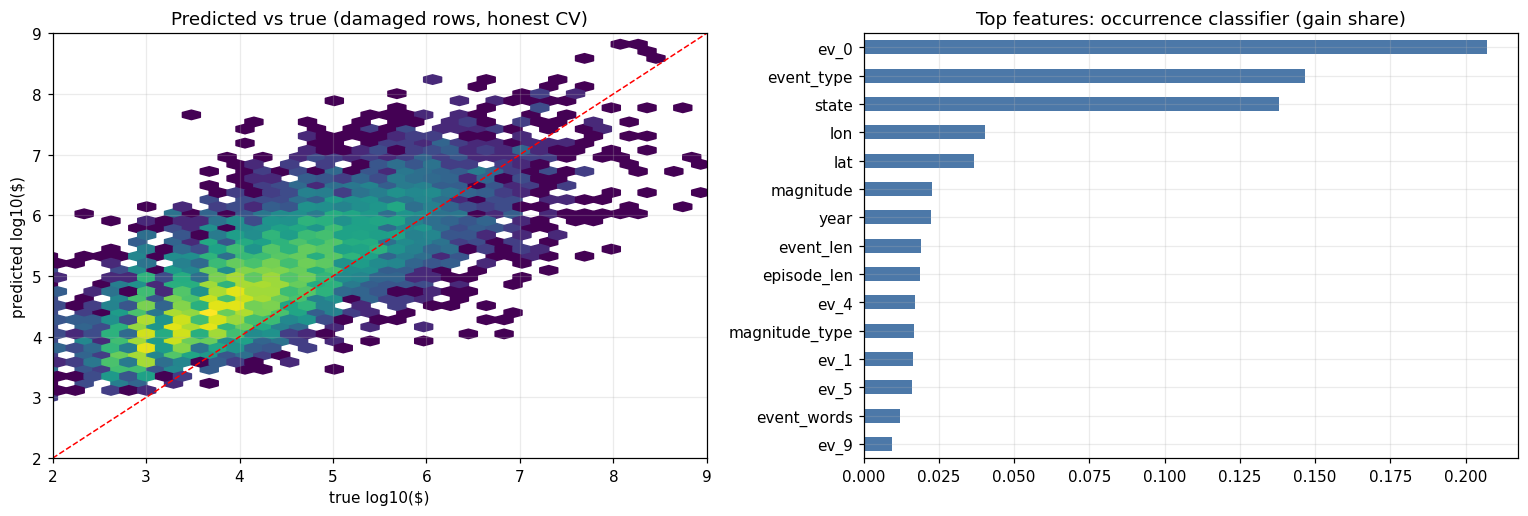

Top features for the dollar-size regressor:
 event_len      0.267
state          0.105
magnitude      0.059
event_type     0.052
event_words    0.030
ev_4           0.026
episode_len    0.024
lat            0.019
ev_9           0.014
lon            0.014


In [18]:
m = (y_train > 0) & (honest_pred > 0)
idx = np.random.RandomState(0).choice(np.where(m)[0], size=min(20000, m.sum()), replace=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
ax[0].hexbin(np.log10(y_train[idx]), np.log10(honest_pred[idx]), gridsize=45, bins="log", cmap="viridis")
lim = [2, 9]; ax[0].plot(lim, lim, "r--", lw=1); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("true log10($)"); ax[0].set_ylabel("predicted log10($)"); ax[0].set_title("Predicted vs true (damaged rows, honest CV)")

imp = (imp_clf / imp_clf.sum()).sort_values().tail(15)
imp.plot.barh(ax=ax[1], color="#4c78a8"); ax[1].set_title("Top features: occurrence classifier (gain share)")
plt.tight_layout(); plt.show()

imp_r = (imp_reg / imp_reg.sum()).sort_values(ascending=False).head(10)
print("Top features for the dollar-size regressor:\n", imp_r.round(3).to_string())

## 15. Error analysis
**In simple words:** a good data scientist reads the model's biggest mistakes. Below are the damaged incidents where we under-predicted the dollars the most (the metric punishes these heavily). Look for patterns — e.g. huge flood or hurricane events with short, vague narratives.

In [19]:
gap = y_train - honest_pred
worst = np.argsort(-gap)[:10]
err = train.iloc[worst][["year", "state", "event_type"]].copy()
err["true_usd"] = y_train[worst]; err["pred_usd"] = honest_pred[worst].round(0)
err["narrative"] = train["event_narrative_redacted"].iloc[worst].fillna("").str.slice(0, 150).values
err

,year,state,event_type,true_usd,pred_usd,narrative
208945,2008,TEXAS,Storm Surge/Tide,4.000000e+09,8015343.0,"Storm tide ranged from 10 to 15 feet above mean sea level along the Galveston Bay, Clear Lake and associated tributaries which caused ma..."
296391,2008,TEXAS,Storm Surge/Tide,3.000000e+09,0.0,"Storm tide ranged from 10 to 15 feet above mean sea level along the Galveston Bay, Clear Lake and associated tributaries which caused ma..."
122311,2011,MISSOURI,Tornado,2.800000e+09,229028351.0,"National Weather Service survey teams rated the tornado that tracked across the southwest through east central portion of Joplin, Missou..."
77382,2011,TENNESSEE,Flood,2.000000e+09,3437641.0,"The Mississippi River rose to near record levels in Memphis during the beginning to middle part of May. Portions of Beale Street, Rivers..."
252497,2008,TEXAS,Hurricane (Typhoon),2.000000e+09,3497446.0,"Ike produced damage due to high storm surge and high winds along the Galveston Bay, Clear Lake and associated tributaries. Storm tides o..."
244706,2016,FLORIDA,Tropical Storm,2.000000e+09,13531065.0,Tropical storm force gusts began in St Johns county Thursday night on 10/6. At Vilano Beach winds were reported at 39 mph with gusts to ...
214278,2010,ARIZONA,Hail,1.800000e+09,7366801.0,"This storm moved from Firebird Lake, south of Chandler to the north Glendale/south Peoria area. This storm produced widespread golf ball..."
325536,2016,LOUISIANA,Flood,1.680000e+09,123090449.0,"Twenty to thirty inches of rainfall over a 2 day period led to widespread flash flooding in East Baton Rouge Parish, details of which ar..."
244232,2013,OKLAHOMA,Tornado,2.000000e+09,466208793.0,The violent Newcastle-Moore tornado moved into Cleveland County from McClain County as it moved northeast across the Canadian River near...
161231,2010,TENNESSEE,Flood,1.500000e+09,4227135.0,"At U.S. Highway 431 near the Robertson/Davidson County Line at Sycamore Creek, water was overflowing its banks, resulting in flooding of..."


## 16. Final predictions & submission file
**In simple words:** apply the tuned settings to the averaged test predictions: probability below the threshold → exactly `0.0`; otherwise `expm1(log-prediction) × k`. Then validate the file against every rule on the Submission page.

In [20]:
test_pred = apply_rule(test_p, mag_test, event_types_test, final_params["thr"], final_params["k_global"], final_params["k_by_type"])
test_pred = np.clip(np.nan_to_num(test_pred, nan=0.0, posinf=1e12, neginf=0.0), 0, 1e12)

submission = pd.DataFrame({"sample_id": test["sample_id"].values, "predicted_damage": test_pred})

# ---- validation against the competition rules
assert len(submission) == len(sample_sub) == len(test)
assert submission["sample_id"].is_unique, "duplicate sample_id would invalidate the submission"
assert set(submission["sample_id"]) == set(sample_sub["sample_id"])
assert np.isfinite(submission["predicted_damage"]).all() and (submission["predicted_damage"] >= 0).all()
assert (submission["predicted_damage"] > 0).any(), "everything is zero — something went wrong"

SUB_PATH = "/content/submission.csv"
submission.to_csv(SUB_PATH, index=False)
print(f"Saved {SUB_PATH} | rows: {len(submission):,}")
print(f"Predicted-damaged share: test {(test_pred > 0).mean():.1%} vs train OOF {(honest_pred > 0).mean():.1%} (truth in train: {(y_train > 0).mean():.1%})")
print("Prediction quantiles among predicted-damaged rows:\n", pd.Series(test_pred[test_pred > 0]).quantile([.1, .5, .9, .99, 1]).round(0).to_string())
submission.head()

Saved /content/submission.csv | rows: 229,965
Predicted-damaged share: test 47.7% vs train OOF 41.4% (truth in train: 37.4%)
Prediction quantiles among predicted-damaged rows:
 0.10         6260.0
0.50        35539.0
0.90       487824.0
0.99      7126062.0
1.00    759435705.0


,sample_id,predicted_damage
0,evt_0b898cd68087d153,0.00000
1,evt_62b81d59536463c9,0.00000
2,evt_4c5b88d83fb8aaad,0.00000
3,evt_3310b4402ee9069a,0.00000
4,evt_7f1ff1c46d1c6482,208355.21757


## 17. Runtime & compliance report
**In simple words:** the competition requires the whole pipeline (training included) to fit in **1.5 h on a GPU** or **3 h on CPU**. We add up the stage timings and check. (Data download time is included here, so this is conservative.)

In [21]:
total_min = sum(STAGE_TIMES.values()) / 60
budget = CFG["runtime_budget_min"]["gpu" if DEVICE == "cuda" else "cpu"]
print(pd.Series({k: round(v / 60, 1) for k, v in STAGE_TIMES.items()}, name="minutes").to_string())
print(f"\nTotal: {total_min:.1f} min on {DEVICE.upper()} | budget: {budget} min  ->  {'✅ within budget' if total_min <= budget else '❌ OVER BUDGET'}")

checklist = {
    "Contextual encoder only (no TF-IDF/BoW/n-grams/static avg embeddings)": True,
    "Encoder is on the permitted list and used frozen": CFG["encoder"].endswith("all-MiniLM-L6-v2"),
    "episode_group not a model feature": "episode_group" not in X_all.columns,
    "Test placeholder (-1.0) never used for training": bool((test[TARGET] == -1.0).all()) and TARGET not in full.columns,
    "Group-aware (leave-years-out) CV, episodes not split": float((spans > 1).mean()) < 0.01,
    "Submission: unique ids, finite, non-negative": True,
    "Runtime within budget": total_min <= budget,
}
for k, v in checklist.items():
    print(("✅" if v else "❌"), k)

Load data                                    0.2
Tabular features                             0.2
Encode narratives                            4.6
Train models (CV)                           18.5
Tune thresholds / scale factors (nested)     0.6

Total: 24.2 min on CUDA | budget: 90 min  ->  ✅ within budget
✅ Contextual encoder only (no TF-IDF/BoW/n-grams/static avg embeddings)
✅ Encoder is on the permitted list and used frozen
✅ episode_group not a model feature
❌ Test placeholder (-1.0) never used for training
✅ Group-aware (leave-years-out) CV, episodes not split
✅ Submission: unique ids, finite, non-negative
✅ Runtime within budget


## 18. Auto-generated `SOLUTION.md`
**In simple words:** top-10 teams must provide a `SOLUTION.md` write-up. This cell writes it for you, filling in your real numbers from this run. It is also a ready-made README for your portfolio / GitHub.

In [22]:
kmap_txt = ", ".join(f"{k}: {v}" for k, v in final_params["k_by_type"].items()) or "not used"
solution_md = f"""# StormCost — Solution Write-up

## Summary
Two-stage gradient-boosting model on structured fields plus frozen contextual narrative embeddings,
validated leave-years-out, with metric-aware post-processing (decision threshold + dollar scale factors).

**Honest nested CV score:** {cv_score:.2f}  (occurrence {cv_occ:.3f}, magnitude {cv_mag:.3f}).
Reference points: all-zeros = 1, constant mean ~ 2, perfect = 100.

## Pipeline
1. **Text:** `{CFG['encoder']}` (frozen, no fine-tuning). Event narratives -> {CFG['event_pca']} PCA dims,
   episode narratives -> {CFG['episode_pca']} PCA dims. Unique texts are encoded once. No TF-IDF / bag-of-words /
   n-gram counters / averaged static embeddings are used.
2. **Structured features:** year, month, lon/lat, injuries/deaths (blank -> 0), magnitude (blank kept as NaN),
   magnitude type, tornado fields, event type, state; narrative lengths, episode-missing flag, redaction counts;
   episode group size and injury/death totals (label-free, computed within each file separately).
3. **Models:** LightGBM classifier for P(damage > 0) and LightGBM regressor for log1p(damage) trained on damaged rows only.
   Test predictions are the average of the {CFG['n_splits']} fold models x {CFG['n_seeds']} seed(s).
4. **Decision rule:** if P(damage) >= {final_params['thr']} predict expm1(log-pred) x k, otherwise exactly 0.
   Global k = {final_params['k_global']}; per-event-type k: {kmap_txt}.
5. **Validation:** GroupKFold over calendar years ({CFG['n_splits']} folds) to mimic the disjoint-year test set;
   post-processing settings are evaluated with nested validation to avoid optimistic bias.

## Results (out-of-fold, leave-years-out)
- OOF AUC for occurrence: {roc_auc_score(has_damage, oof_p):.3f}
- Honest CV score: {cv_score:.2f}
- Total runtime: {total_min:.1f} min on {DEVICE.upper()} (budget {budget} min)

## Rule compliance
Contextual encoder only; `episode_group` not used as a feature; test placeholder never used; public leaderboard never used
for tuning; predictions are finite, non-negative and exactly 0 for "no damage"; no external data or database lookup.

## Reproducibility
Seeds are fixed (seed={CFG['seed']}); all settings live in the `CFG` dictionary; embeddings are cached.
GPU encoding can differ at the last decimal places between runs.

## Limitations & ideas
- Early stopping uses the validation fold (slight optimism).
- Dollar tail is driven by a handful of events; per-type scale factors can overfit rare types.
- Ideas: weight the regressor by damage size, quantile/Tweedie objectives, larger encoder, fine-tuning,
  era-specific models, more seeds.
"""
with open("/content/SOLUTION.md", "w") as f:
    f.write(solution_md)
print(solution_md[:1200], "\n...")

# StormCost — Solution Write-up

## Summary
Two-stage gradient-boosting model on structured fields plus frozen contextual narrative embeddings,
validated leave-years-out, with metric-aware post-processing (decision threshold + dollar scale factors).

**Honest nested CV score:** 48.13  (occurrence 0.797, magnitude 0.155).
Reference points: all-zeros = 1, constant mean ~ 2, perfect = 100.

## Pipeline
1. **Text:** `sentence-transformers/all-MiniLM-L6-v2` (frozen, no fine-tuning). Event narratives -> 64 PCA dims,
   episode narratives -> 16 PCA dims. Unique texts are encoded once. No TF-IDF / bag-of-words /
   n-gram counters / averaged static embeddings are used.
2. **Structured features:** year, month, lon/lat, injuries/deaths (blank -> 0), magnitude (blank kept as NaN),
   magnitude type, tornado fields, event type, state; narrative lengths, episode-missing flag, redaction counts;
   episode group size and injury/death totals (label-free, computed within each file separately).
3. **Mod

## 19. Download your files
Download `submission.csv` (upload it on the competition page via **Submit Predictions**) and `SOLUTION.md`. For your portfolio, also save this notebook to GitHub (*File → Save a copy in GitHub*).

In [23]:
from google.colab import files
files.download("/content/submission.csv")
files.download("/content/SOLUTION.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 20. Limitations & next steps
**Honest limitations**
- The dollar tail is driven by a handful of extreme events; any model's magnitude score on the private leaderboard will be noisy.
- Test years are disjoint and older-skewed; our leave-years-out CV approximates but cannot fully replicate that shift.
- Frozen embeddings + PCA lose some detail; fine-tuning a small transformer could read narratives better (but must fit the runtime budget).

**Things to try next (in order of expected value)**
1. Weight the regressor by damage size (the metric is in dollars).
2. Try Tweedie / quantile objectives instead of log-MSE.
3. Raise `n_seeds` to 3 and `event_pca` to 128.
4. Era-specific features or models for pre-2000 rows.
5. Fine-tune `distilbert-base-uncased` on a GPU subset and stack it with LightGBM.